In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

# 从当前目录向上找 .git，定位根目录
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT/".git").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
# 把项目根目录加入到sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from src.config import DB_PATH, FIGURES_DIR, ensure_dirs

ensure_dirs()

# 设置中文字体以及负号显示
from src.viz import apply_chinese, get_font_prop

font_prop = get_font_prop()
plt.rcParams["axes.unicode_minus"] = False


con = duckdb.connect(str(DB_PATH),read_only=True)


使用字体: C:/Windows/Fonts/msyh.ttc


In [34]:
# 将数据分以天为组，统计每天的去重后的用户数、统计每日的页面访问量
daily = con.sql("""
SELECT 
    DATE_TRUNC('day',time) AS dt,
    COUNT(DISTINCT user_id) AS 'DAU',
    COUNT(*) AS 'PV'
FROM user_behavior
GROUP BY dt
ORDER BY dt
""").df()

# 将数据按一天的小时的维度来分，统计去重后的用户数，以及页面访问量
hourly = con.sql("""
SELECT 
    EXTRACT(hour FROM time) AS hour,
    COUNT(DISTINCT user_id) AS uv,
    COUNT(*) AS pv
FROM user_behavior
GROUP BY hour
ORDER BY hour
""").df()

# 将数据按星期分组，统计去重后的用户数，以及页面访问量
dow = con.sql("""
SELECT 
    DAYOFWEEK(time) AS dow,
    COUNT(*) AS pv,
    COUNT(DISTINCT user_id) AS uv
FROM user_behavior
GROUP BY dow
ORDER BY dow
""").df()
dow



,dow,pv,uv
0,0,804865,9193
1,1,790073,9281
2,2,981404,9428
3,3,983358,9465
4,4,1008972,9474
5,5,871392,9312
6,6,773315,9194


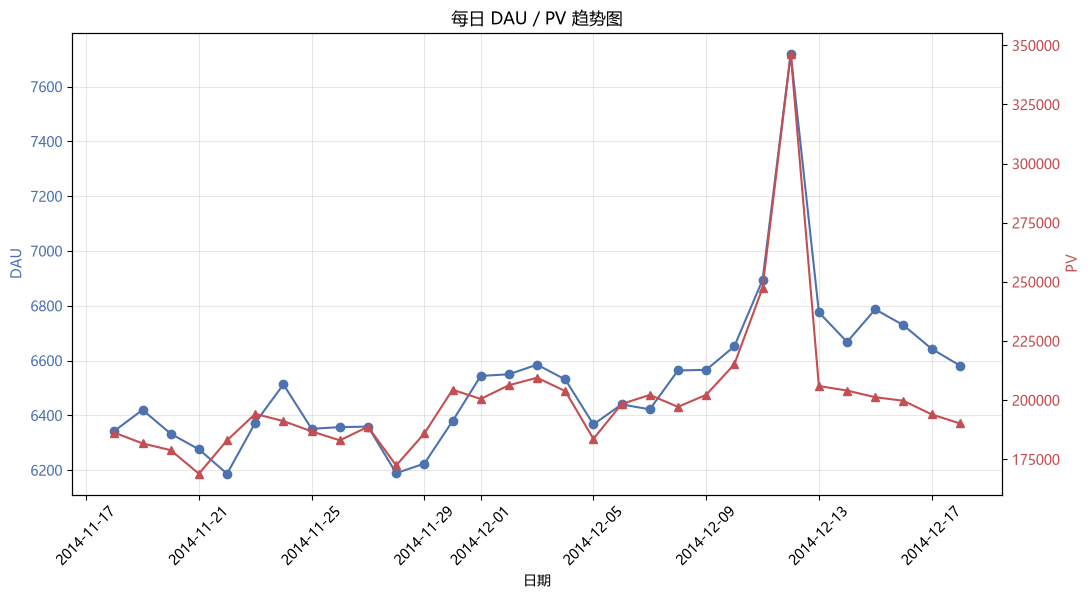

In [20]:
# 图1 DAV/PV趋势

fig, ax1 = plt.subplots(figsize = (12,6))
ax1.plot(daily["dt"], daily["DAU"], color = "#4C72B0",marker="o",label="DAU")
ax1.set_xlabel("日期")
ax1.set_ylabel("DAU", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True,alpha = 0.3)
apply_chinese(ax1,font_prop)

ax2 = ax1.twinx()
ax2.plot(daily["dt"],daily["PV"],color="#C44E52", marker="^",label="PV")
ax2.set_ylabel("PV",color = "#C44E52")
ax2.tick_params(axis="y",labelcolor="#C44E52")
apply_chinese(ax2,font_prop)


plt.title("每日 DAU / PV 趋势图")
plt.savefig(FIGURES_DIR/"daily_trend.png")
plt.show()

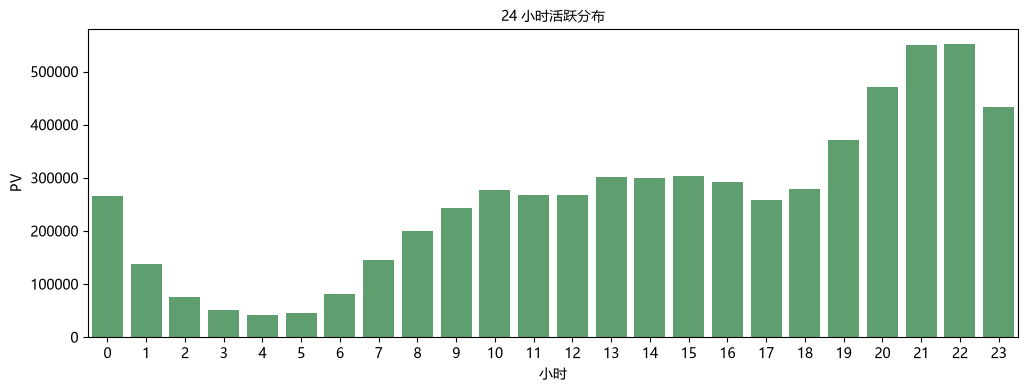

In [29]:
# 时段活跃热力
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=hourly, x="hour", y="pv", ax=ax, color="#55A868")
ax.set_xlabel("小时")
ax.set_ylabel("PV")
ax.set_title("24 小时活跃分布")
apply_chinese(ax,font_prop)

plt.savefig(FIGURES_DIR / "hourly_active.png")
plt.show()

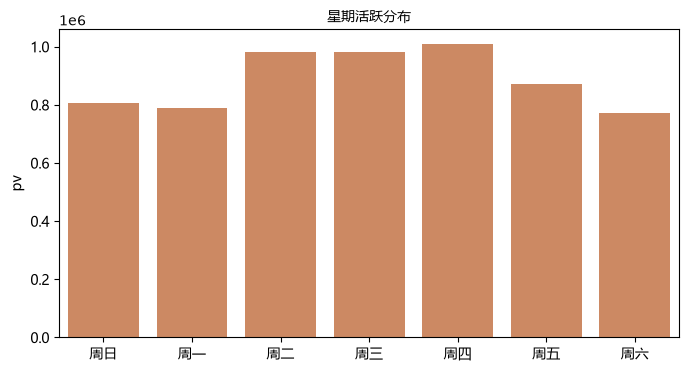

In [38]:
# 星期活跃分布
dow_map = {0:"周日",1:"周一",2:"周二",3:"周三",4:"周四",5:"周五",6:"周六"}
dow["dow_name"] = dow['dow'].map(dow_map)

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=dow,x="dow_name", y ="pv", ax=ax,color="#dd8452")
ax.set_xlabel('')
ax.set_title("星期活跃分布")
apply_chinese(ax,font_prop)

plt.savefig(FIGURES_DIR/"dow_active.png")
plt.show()